Importando as bibliotecas e módulos necessários: 

In [1]:
#!pip install matplotlib
#!pip install pyarrow
import os
import pandas as pd
import numpy as np
import sys
import gc
import matplotlib.pyplot as plt

Carregando a base a ser utilizada:

In [2]:
df_final = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_UNIF.parquet", engine="pyarrow")

### Análise Exploratória dos dados
Esta seção concentra-se na discussão das principais descobertas da análise exploratória de dados (AED). Em particular, três questões de AED foram formuladas e investigadas com o uso de resumos numéricos (medidas de tendência central, medidas de dispersão e correlação). Informações adicionais também puderam ser obtidas a partir de suas respectivas visualizações.

#### 1. Quantidade de alunos por ano
O objetivo é comparar a participação entre os anos

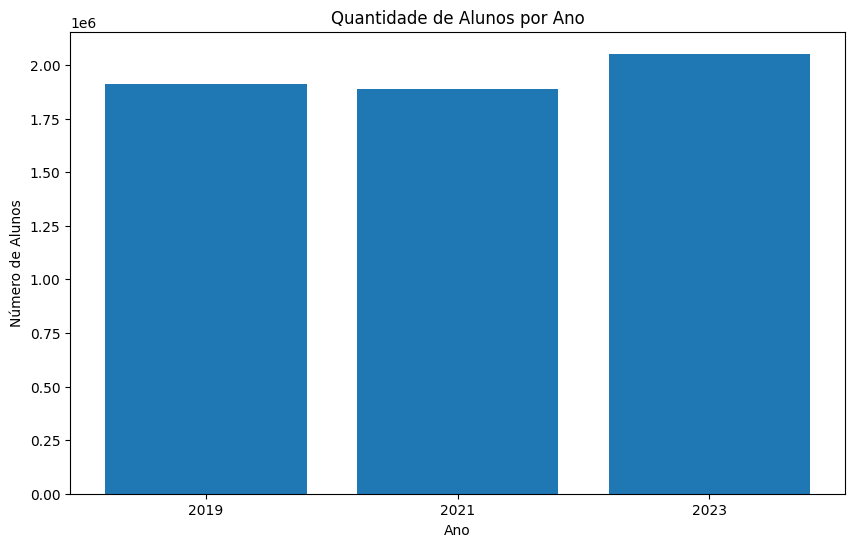

In [3]:
quantidade = (
    df_final["ANO"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.bar(
    quantidade.index.astype(str),
    quantidade.values
)

plt.title("Quantidade de Alunos por Ano")
plt.xlabel("Ano")
plt.ylabel("Número de Alunos")

plt.show()

#### 2. Evolução da proficiência
O objetivo é comparar a evolução da proficiência entre os anos

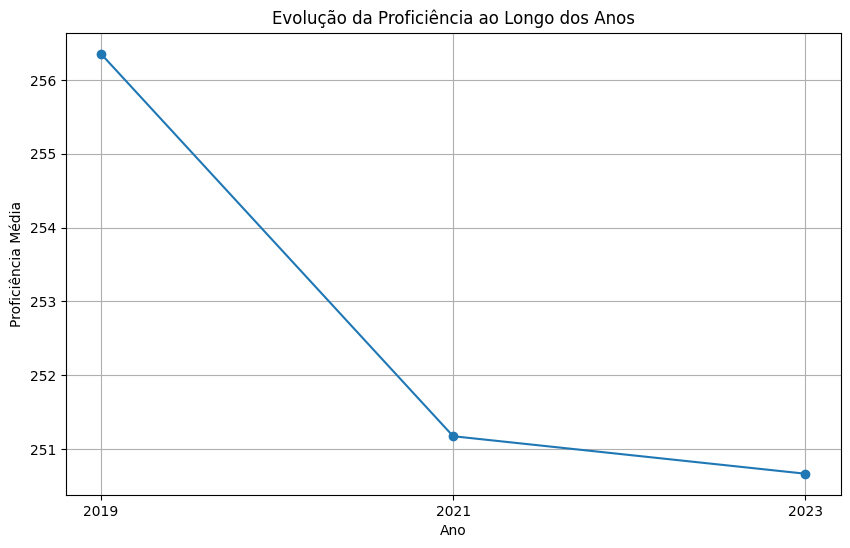

In [41]:
df_final["PROFICIENCIA_SAEB"] = pd.to_numeric(
    df_final["PROFICIENCIA_SAEB"],
    errors="coerce"
)

media_prof = df_final.groupby("ANO")["PROFICIENCIA_SAEB"].mean()

media_prof.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)

plt.xticks(media_prof.index)

plt.title("Evolução da Proficiência ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("Proficiência Média")

plt.grid(True)

plt.show()

#### 3. Participação x Proficiência
O objetivo é analisar se mudanças na proficiência podem estar relacionadas ao aumento/redução da participação

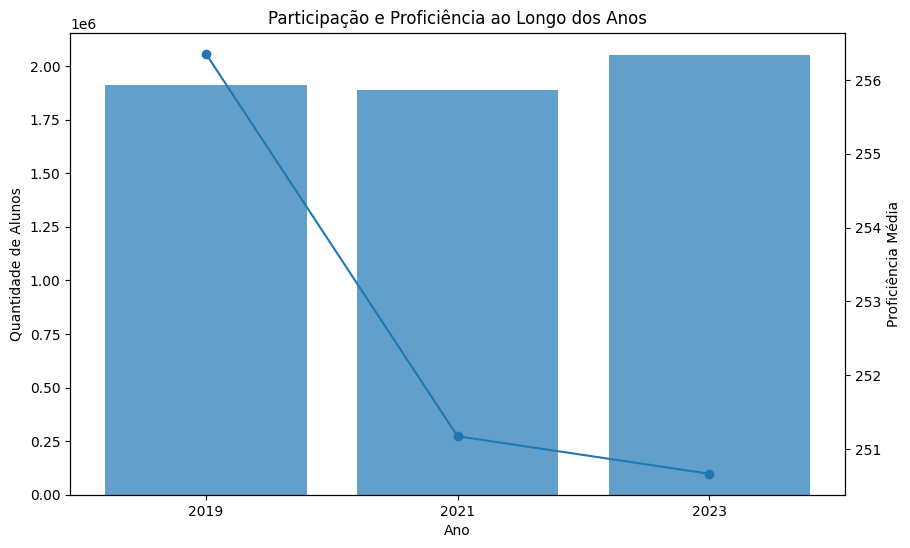

In [43]:
participacao = df_final.groupby("ANO")["ID_ALUNO"].nunique()

proficiencia = df_final.groupby("ANO")["PROFICIENCIA_SAEB"].mean()

fig, ax1 = plt.subplots(figsize=(10,6))

# ----- participação -----
ax1.bar(
    participacao.index.astype(str),
    participacao.values,
    alpha=0.7
)

ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de Alunos")

# ----- proficiência -----
ax2 = ax1.twinx()

ax2.plot(
    proficiencia.index.astype(str),
    proficiencia.values,
    marker="o"
)

ax2.set_ylabel("Proficiência Média")

plt.title("Participação e Proficiência ao Longo dos Anos")

plt.show()

#### 4. Bloxpot proficiência por ano 
O objetivo é analisar mediana, quartis, dispersão e outliers

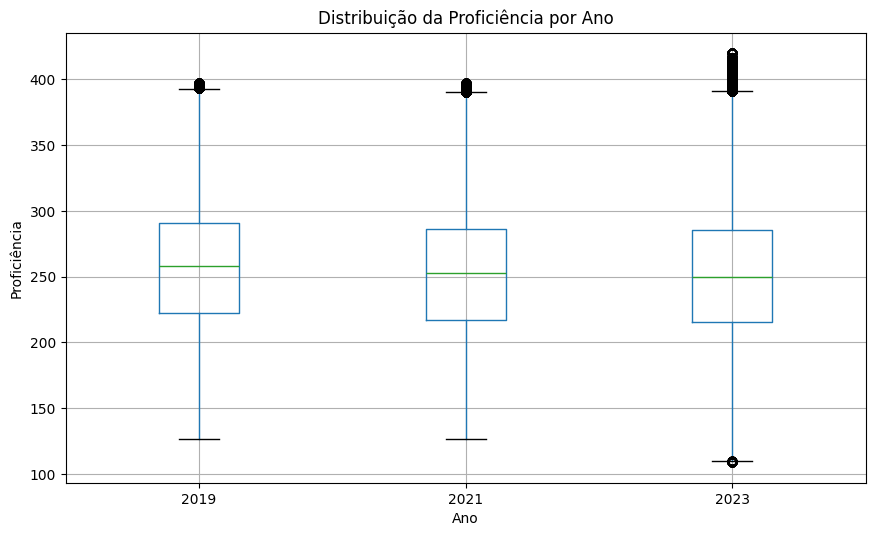

In [6]:
df_final.boxplot(
    column="PROFICIENCIA_SAEB",
    by="ANO",
    figsize=(10,6)
)

plt.title("Distribuição da Proficiência por Ano")
plt.suptitle("") 

plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.show()

#### 5. Distribuição das Variáveis
O objetivo dessa fase foi comparar as respostas para as variáveis categóricas entre os anos

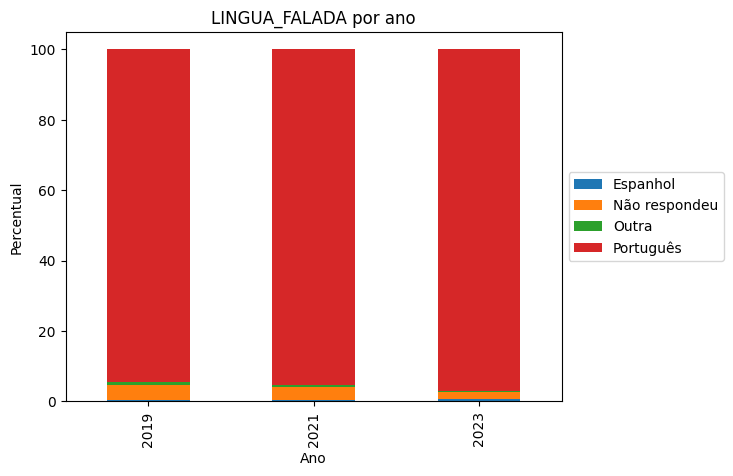

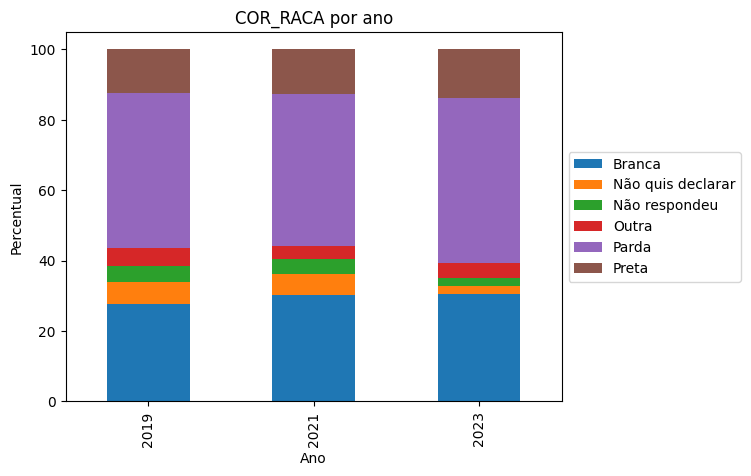

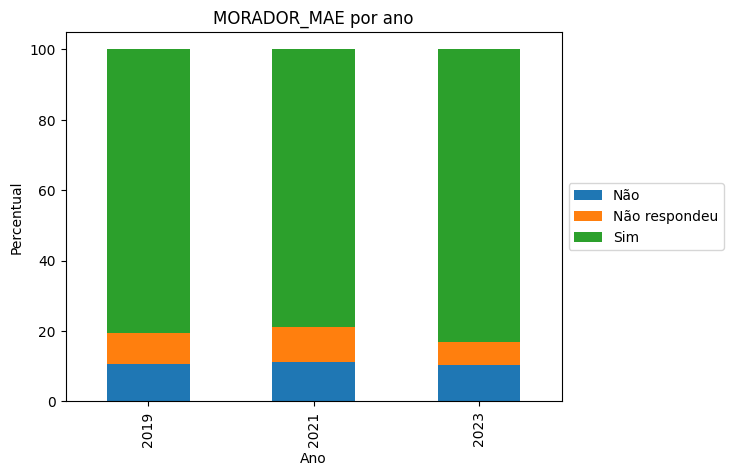

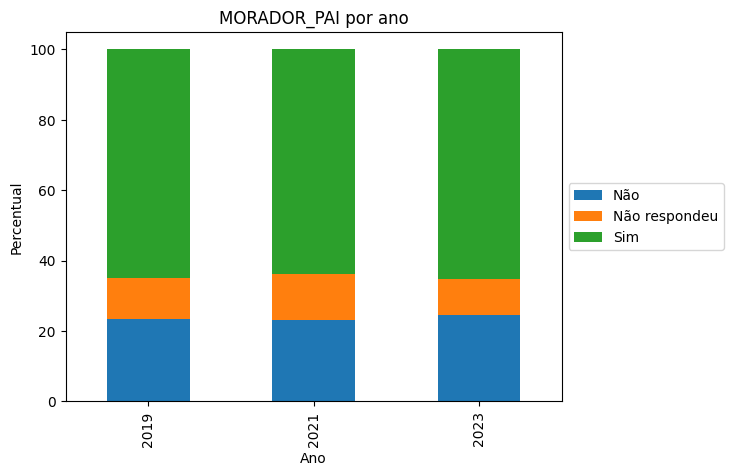

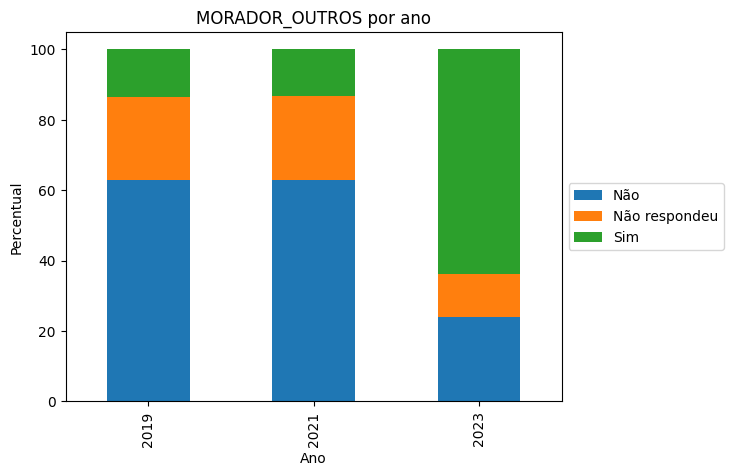

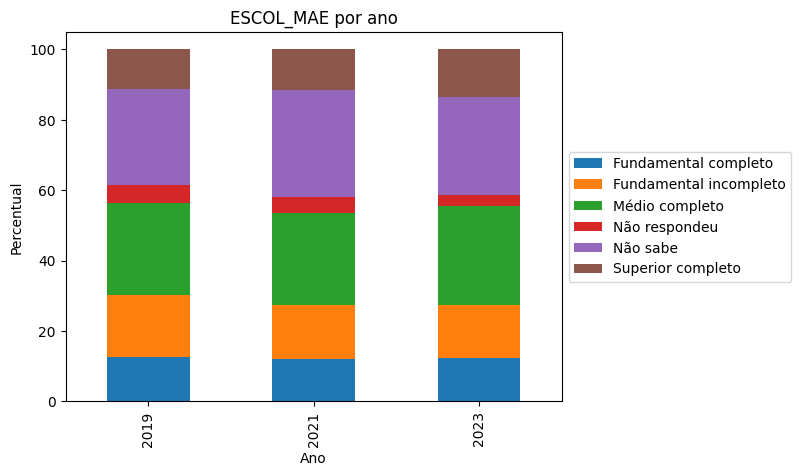

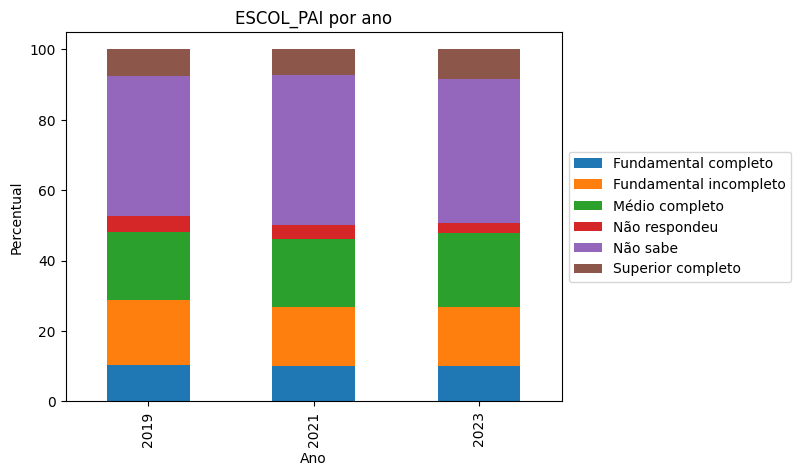

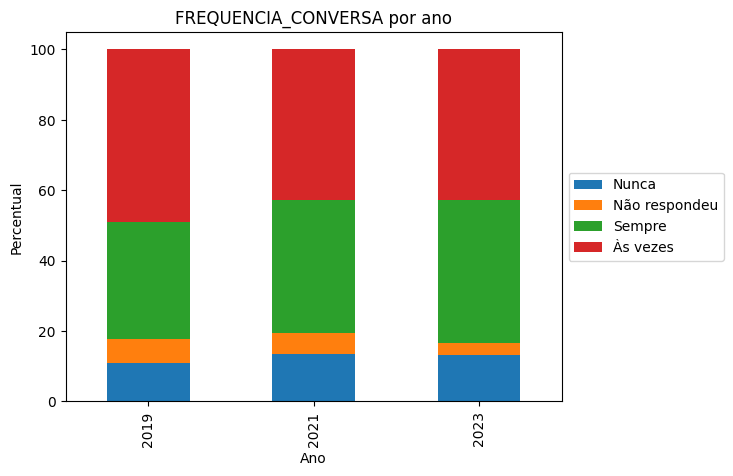

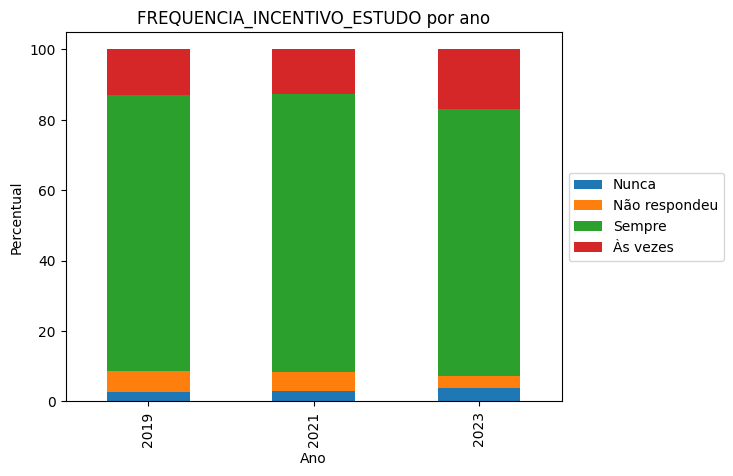

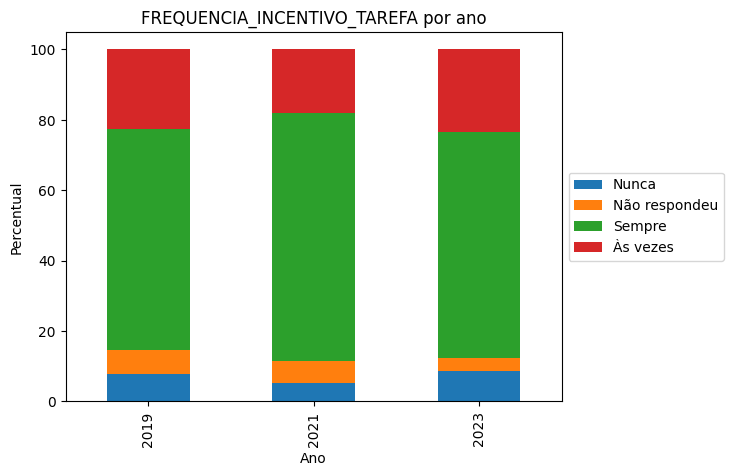

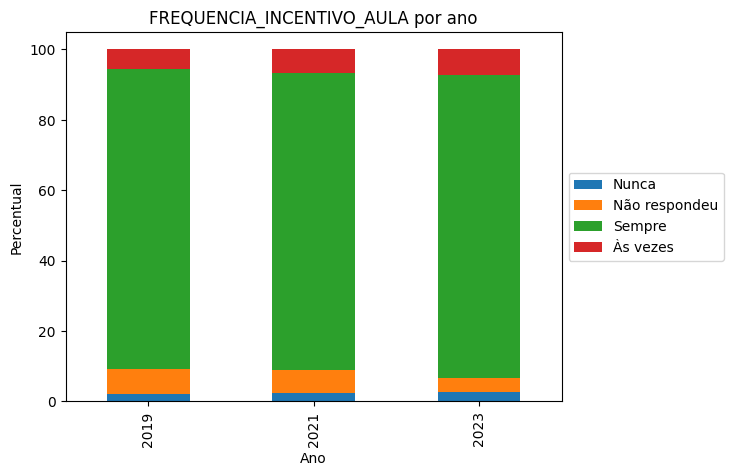

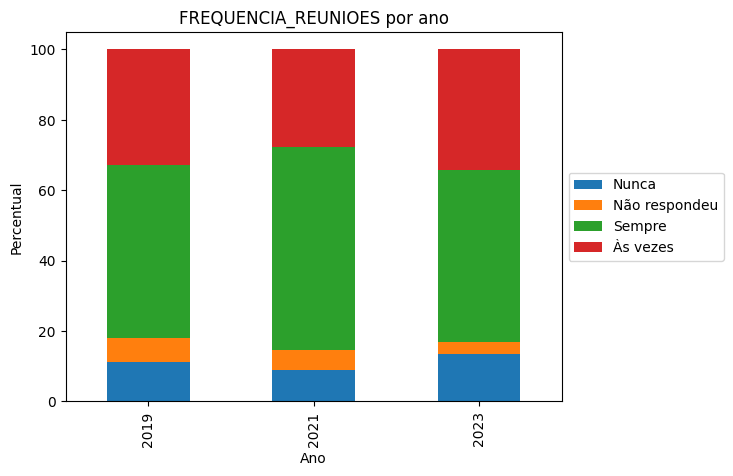

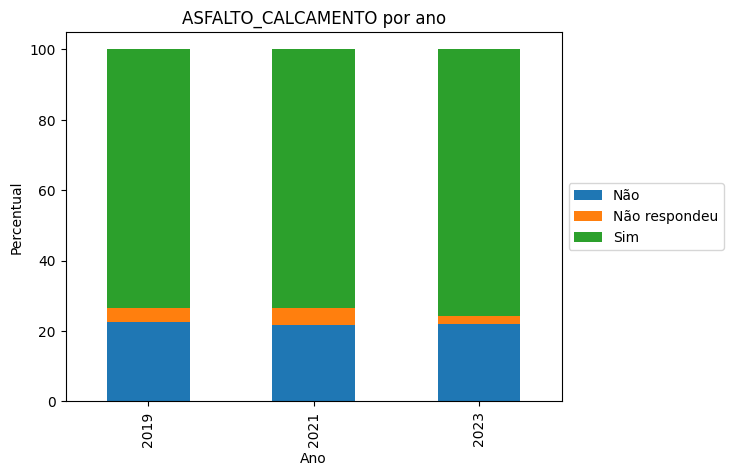

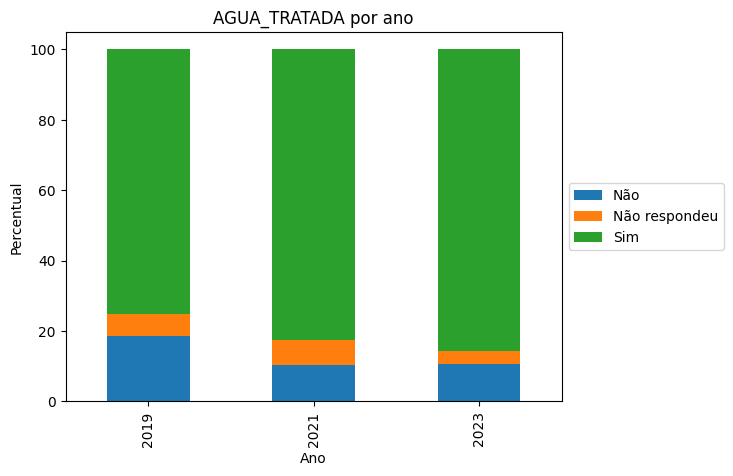

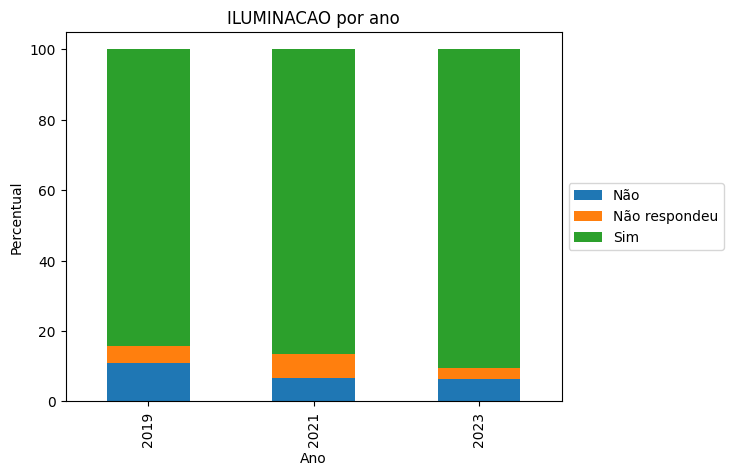

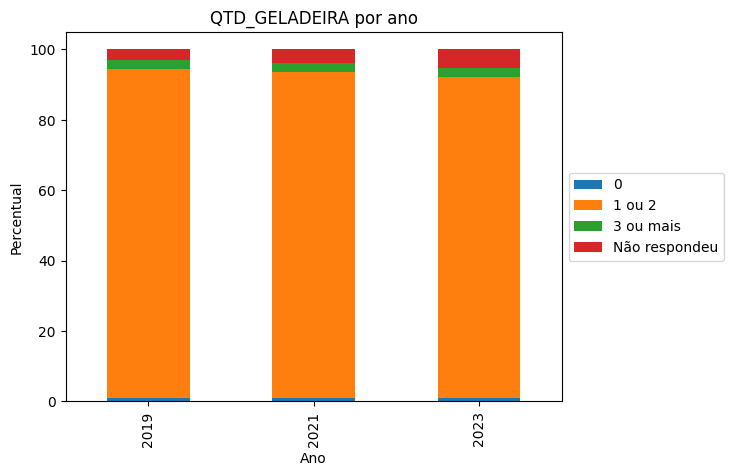

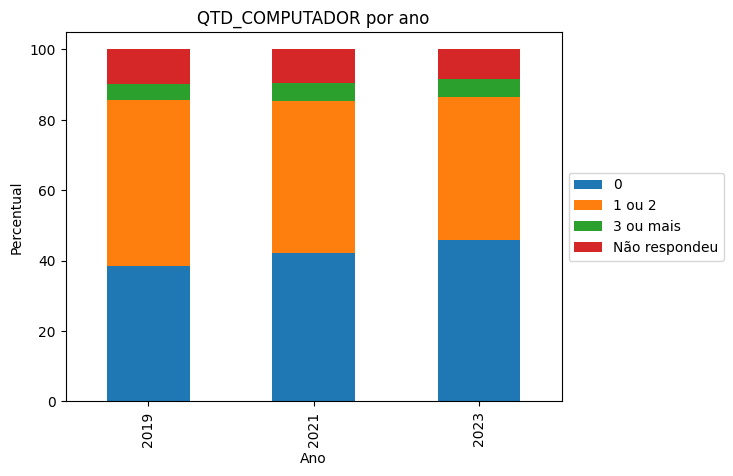

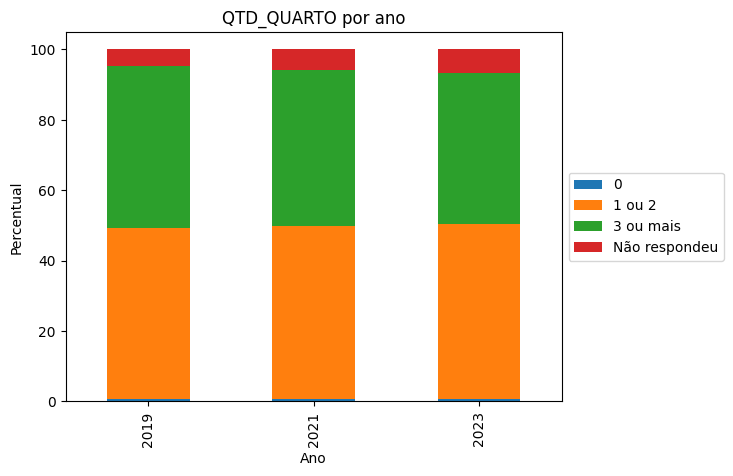

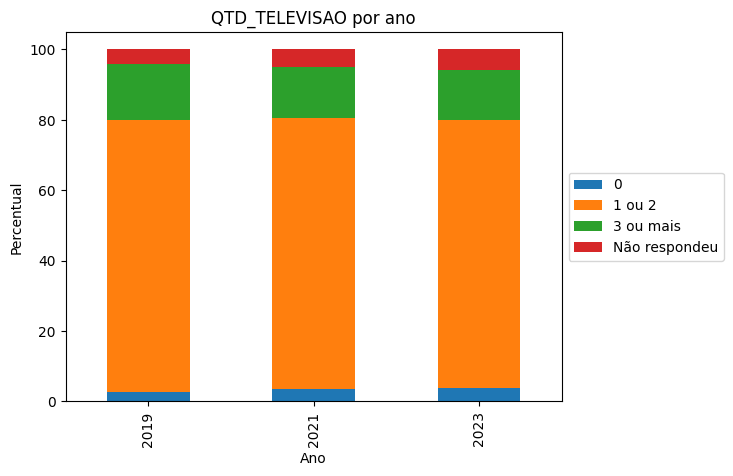

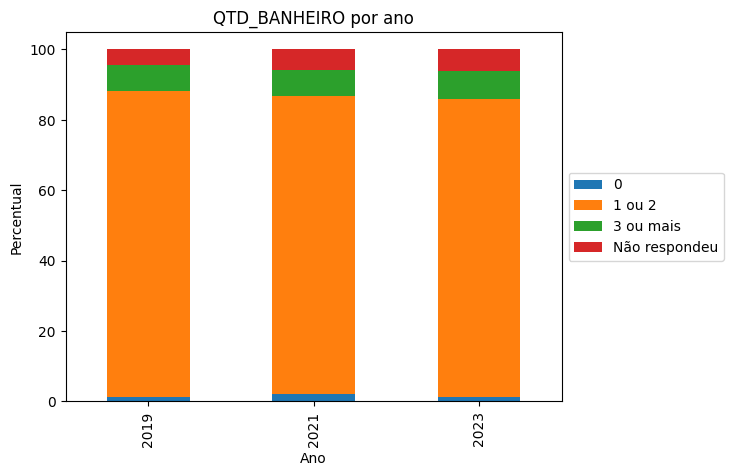

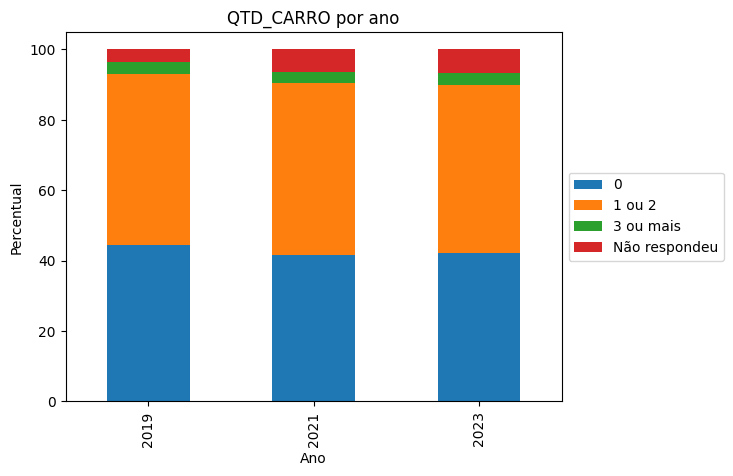

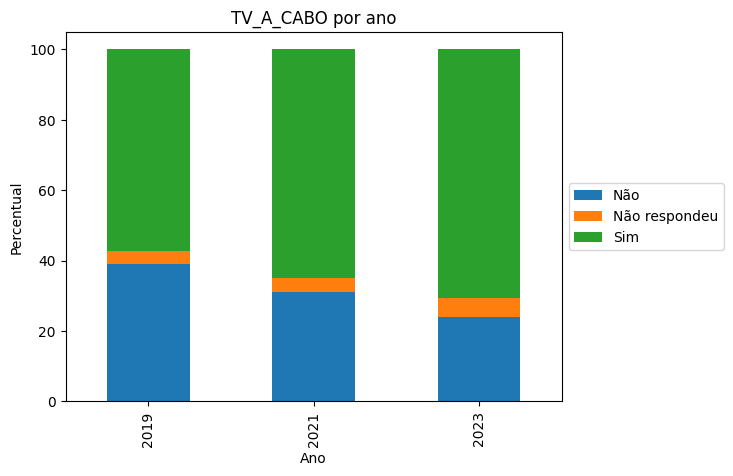

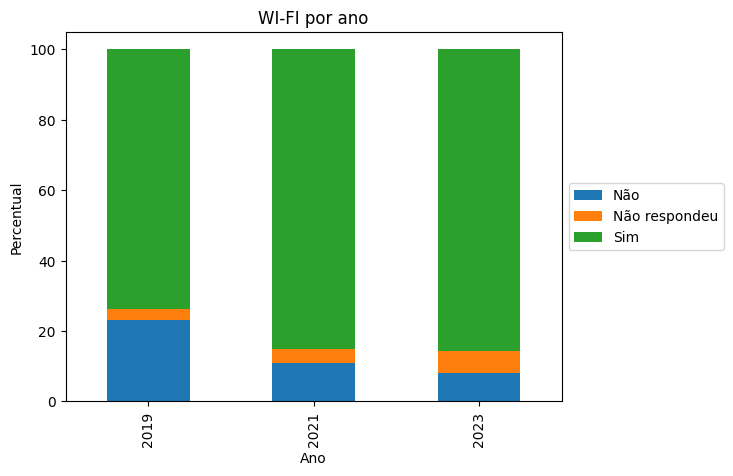

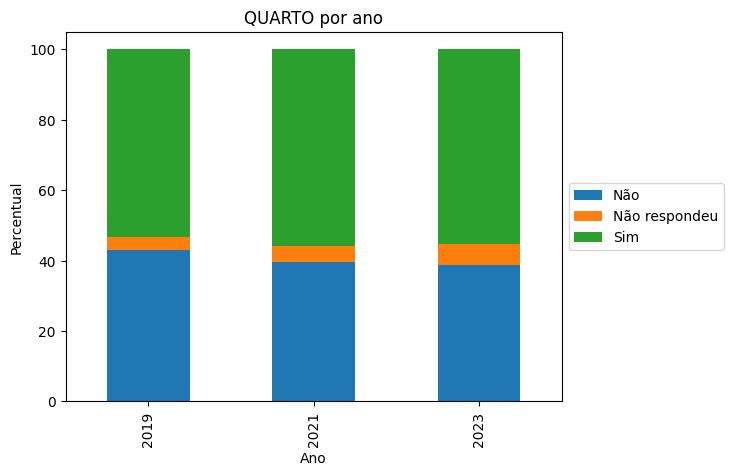

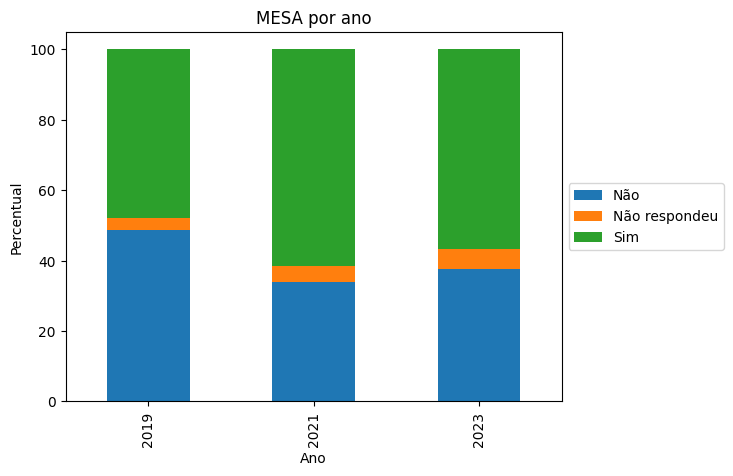

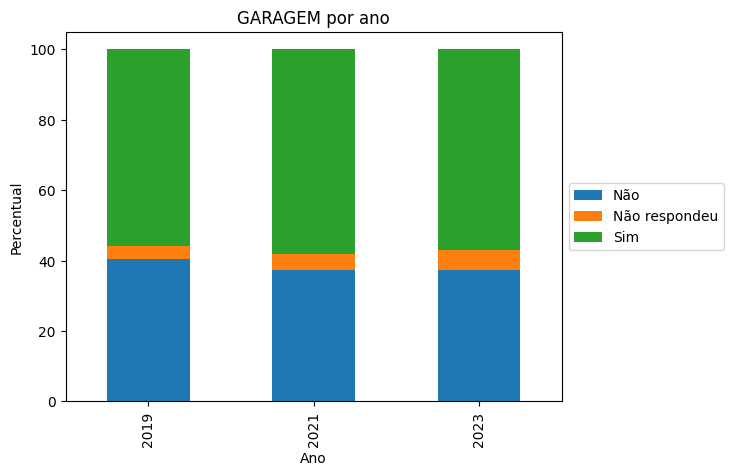

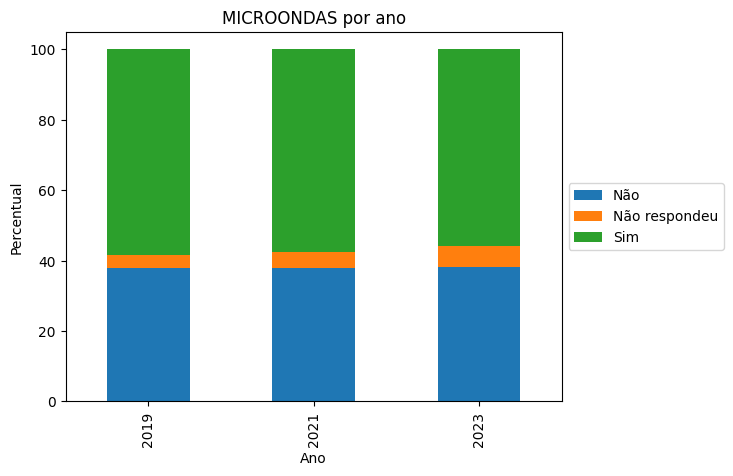

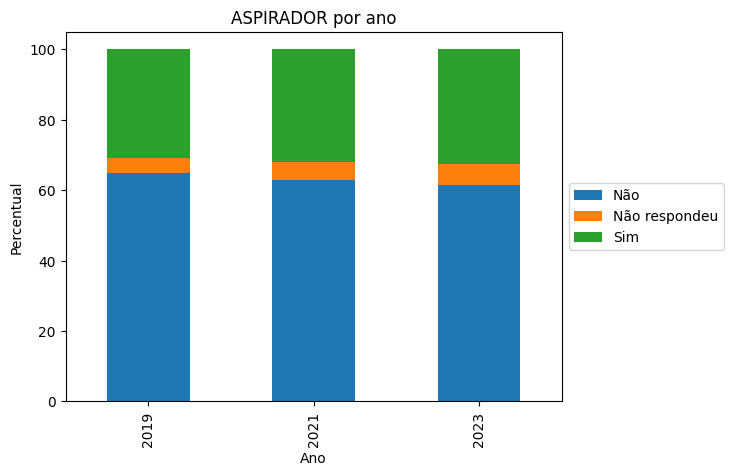

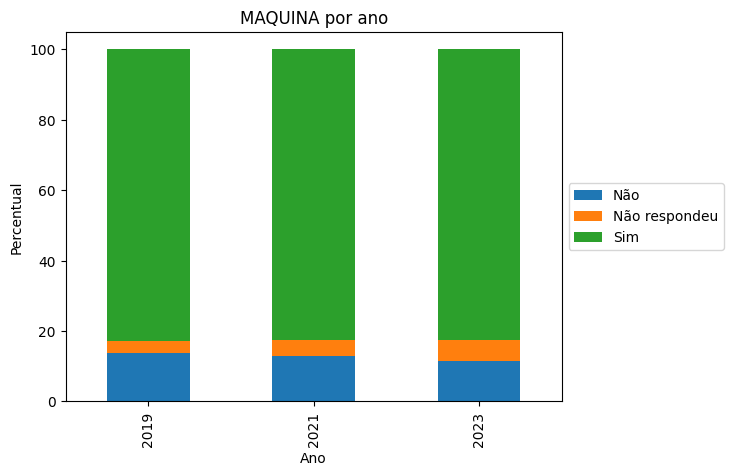

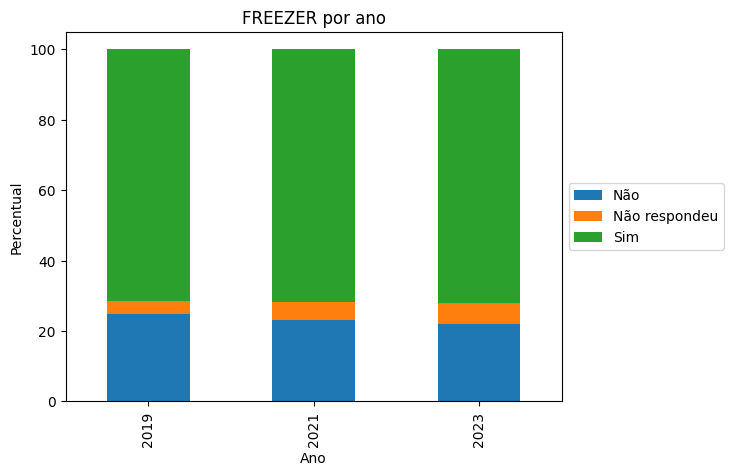

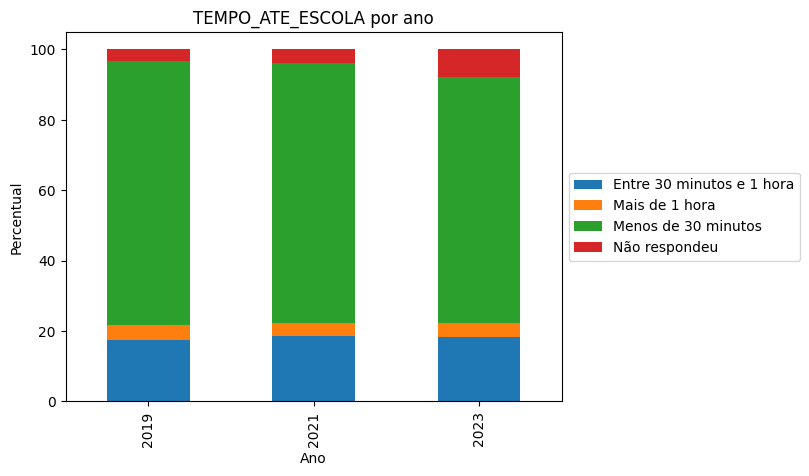

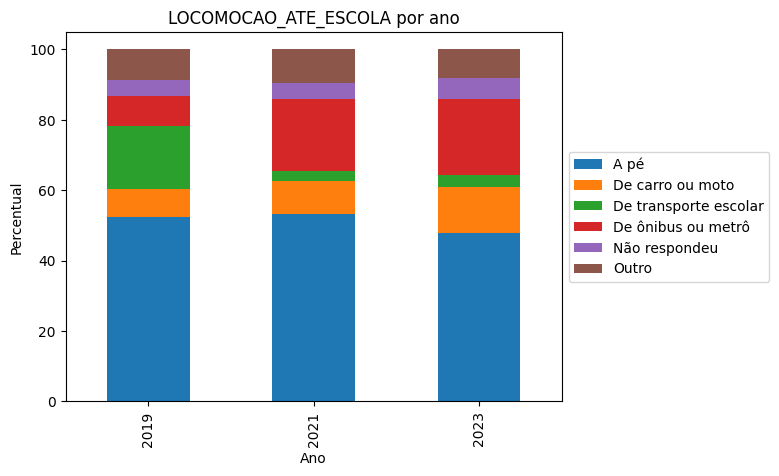

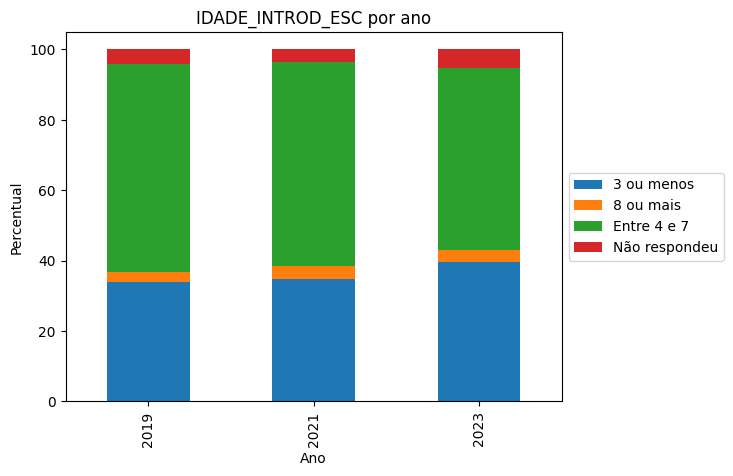

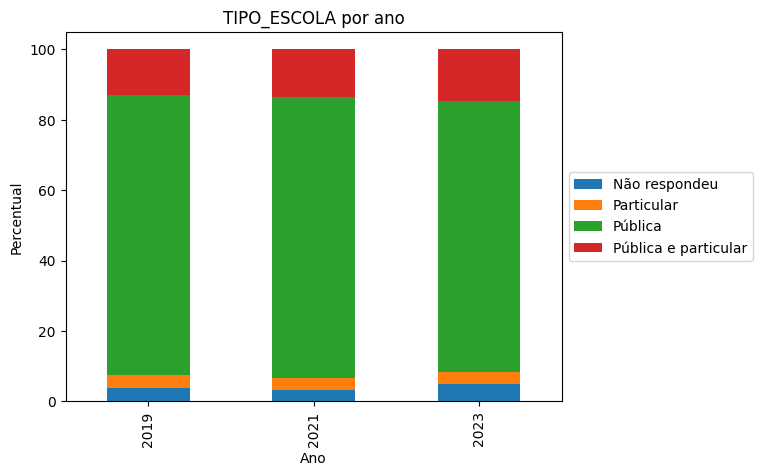

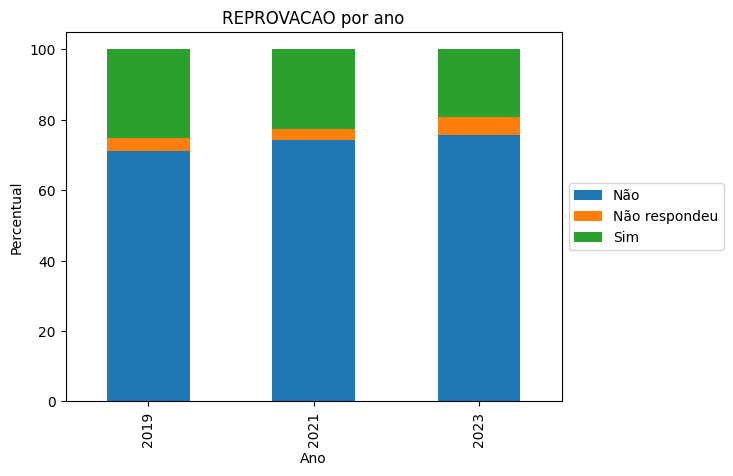

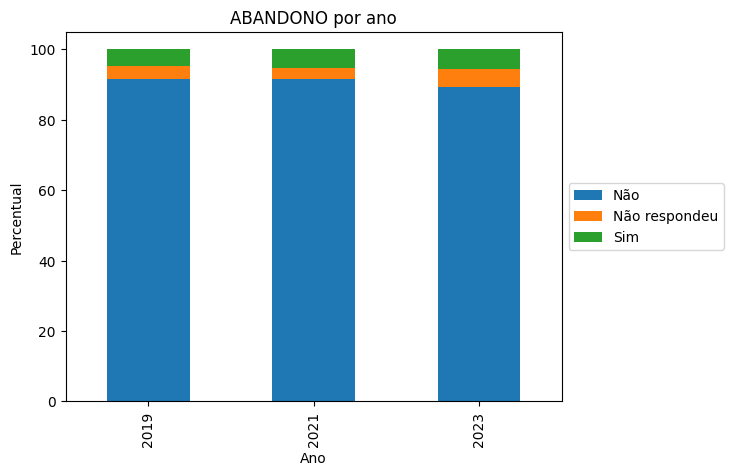

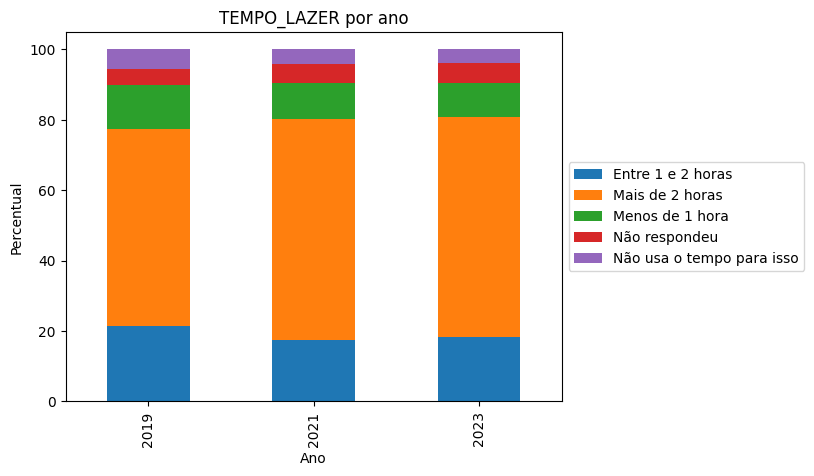

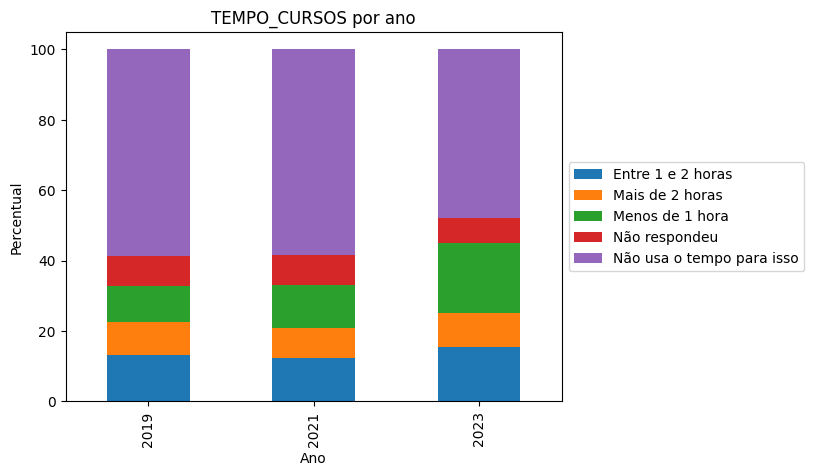

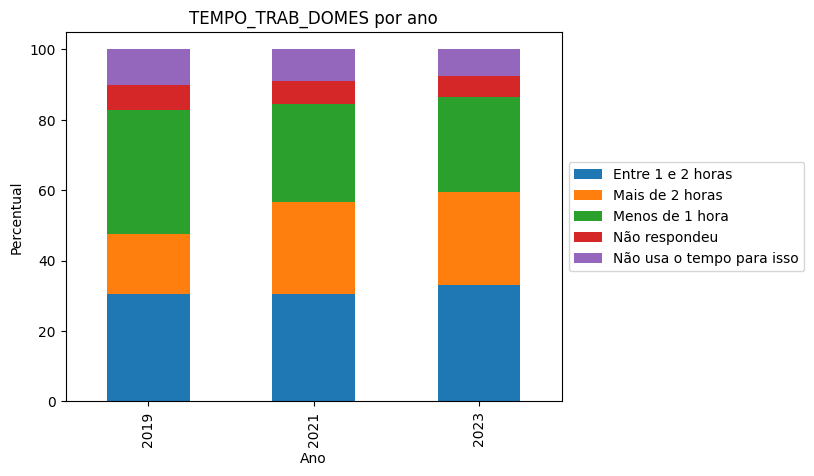

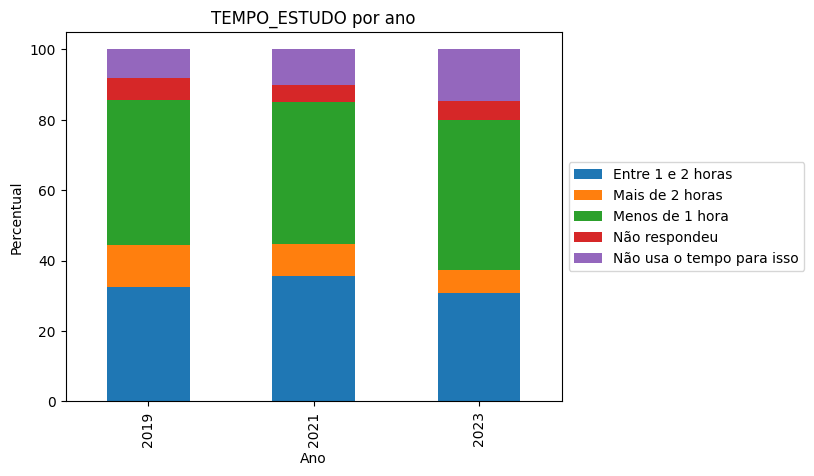

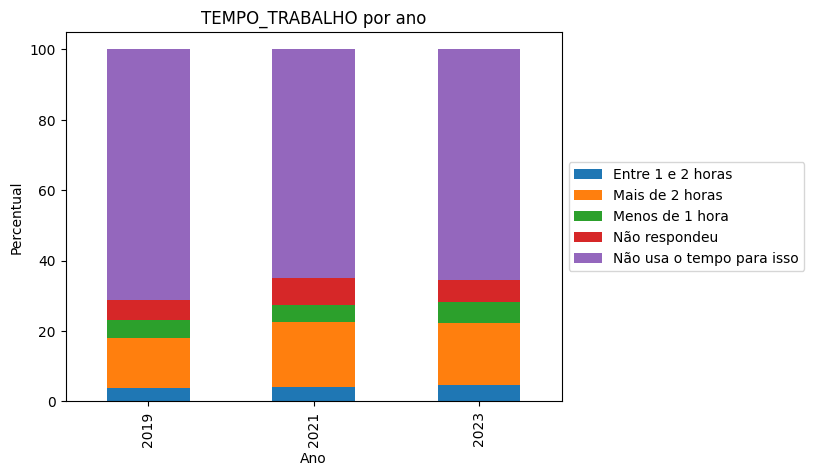

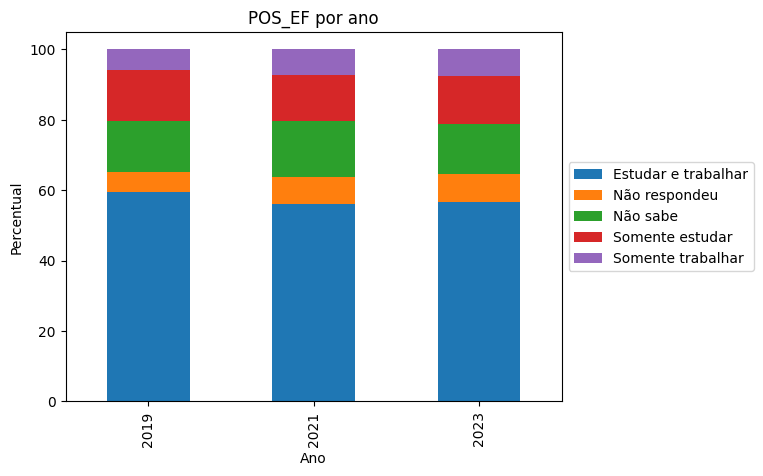

In [48]:
variaveis = [
    "LINGUA_FALADA","COR_RACA","MORADOR_MAE","MORADOR_PAI","MORADOR_OUTROS","ESCOL_MAE","ESCOL_PAI","FREQUENCIA_CONVERSA","FREQUENCIA_INCENTIVO_ESTUDO",
    "FREQUENCIA_INCENTIVO_TAREFA","FREQUENCIA_INCENTIVO_AULA","FREQUENCIA_REUNIOES","ASFALTO_CALCAMENTO","AGUA_TRATADA","ILUMINACAO","QTD_GELADEIRA",
    "QTD_COMPUTADOR","QTD_QUARTO","QTD_TELEVISAO","QTD_BANHEIRO","QTD_CARRO","TV_A_CABO","WI-FI","QUARTO","MESA","GARAGEM","MICROONDAS","ASPIRADOR",
    "MAQUINA","FREEZER","TEMPO_ATE_ESCOLA","LOCOMOCAO_ATE_ESCOLA","IDADE_INTROD_ESC","TIPO_ESCOLA","REPROVACAO","ABANDONO","TEMPO_LAZER","TEMPO_CURSOS",
    "TEMPO_TRAB_DOMES","TEMPO_ESTUDO","TEMPO_TRABALHO","POS_EF"
]
for var in variaveis:
    
    tabela = pd.crosstab(
        df_final["ANO"],
        df_final[var],
        normalize="index"
    ) * 100
    
    tabela.plot(kind="bar", stacked=True)

    plt.legend(
        loc="center left",
        bbox_to_anchor=(1, 0.5)
    )
    plt.title(f"{var} por ano")
    plt.ylabel("Percentual")
    plt.xlabel("Ano")

    plt.show()

Entrando numa etapa mais analítica da pesquisa, agora o objetivo é comparar a evolução da proficiência para alguns aspectos em específico, levando em conta os resultados da análise de distribuição das variáveis relativos a esses aspectos.

#### 6. Proficiência por localização da escola

In [54]:
df_final["LOCALIZACAO"] = df_final["LOCALIZACAO"].replace({
    1: "Urbana",
    2: "Rural"
})
tab = df_final.groupby('LOCALIZACAO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std', 'count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                  Média     Mediana  Desvio_Padrão  Quantidade
LOCALIZACAO                                                   
Rural        239.761624  237.561370      49.803143      641243
Urbana       254.280280  255.396109      48.896862     5209523


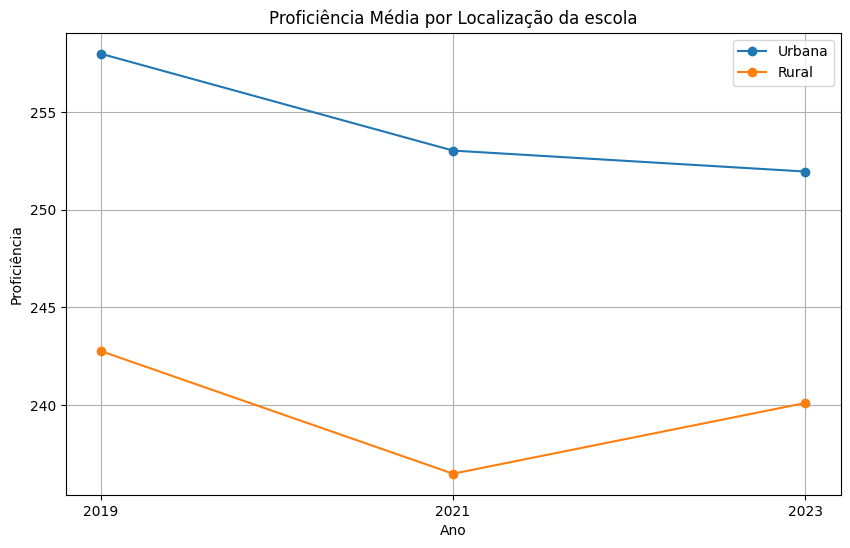

In [24]:
media_local = (
    df_final.groupby(["ANO", "LOCALIZACAO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_local.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_local.index)
plt.legend([
    "Urbana",
    "Rural"
])
plt.title("Proficiência Média por Localização da escola")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 7. Proficiência por cor/raça

In [55]:
tab = df_final.groupby('COR_RACA').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std', 'count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]
print(tab)

                        Média     Mediana  Desvio_Padrão  Quantidade
COR_RACA                                                            
Branca             263.740217  266.490569      49.589905     1728531
Não quis declarar  241.911883  241.595958      48.885202      279955
Não respondeu      239.923618  240.444129      49.194633      208456
Outra              244.708577  244.758710      48.525726      257416
Parda              251.867403  252.199431      48.008757     2619528
Preta              240.510663  240.075324      47.257835      756880


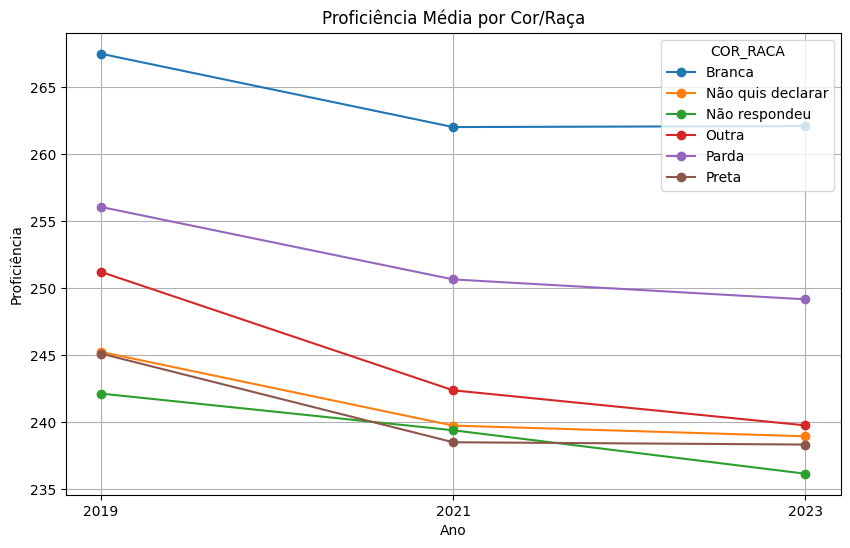

In [21]:
media_cor = (
    df_final.groupby(["ANO", "COR_RACA"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_cor.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_cor.index)
plt.title("Proficiência Média por Cor/Raça")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 8. Proficiência por escolaridade da mãe 

In [56]:
tab = df_final.groupby('ESCOL_MAE').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std', 'count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                             Média     Mediana  Desvio_Padrão  Quantidade
ESCOL_MAE                                                                
Fundamental completo    252.868805  254.224662      48.402963      720393
Fundamental incompleto  243.542647  242.783838      48.044786      936057
Médio completo          262.312904  264.476600      48.080573     1575713
Não respondeu           238.686936  239.109141      48.576525      249431
Não sabe                243.287813  242.825645      47.217122     1657588
Superior completo       270.035553  273.069654      49.695138      711584


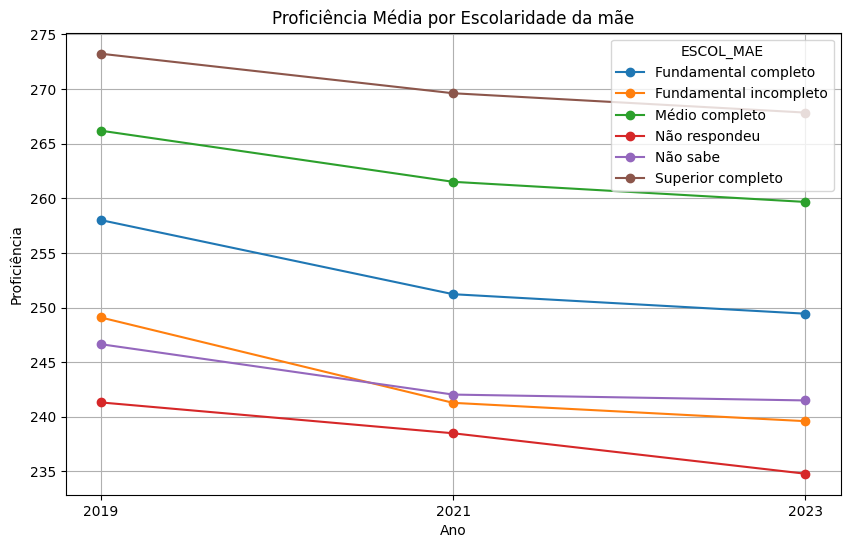

In [10]:
media_escol = (
    df_final.groupby(["ANO", "ESCOL_MAE"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_escol.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_escol.index)
plt.title("Proficiência Média por Escolaridade da mãe")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 9. Proficiência por frequêcia de conversa (sobre o que acontece na escola)

In [57]:
tab = df_final.groupby('FREQUENCIA_CONVERSA').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                          Média     Mediana  Desvio_Padrão  Quantidade
FREQUENCIA_CONVERSA                                                   
Nunca                248.385579  248.802324      49.450004      736750
Não respondeu        222.213301  218.561500      47.959256      310365
Sempre               255.379463  256.111419      49.367518     2180117
Às vezes             255.267137  256.269874      47.832429     2623534


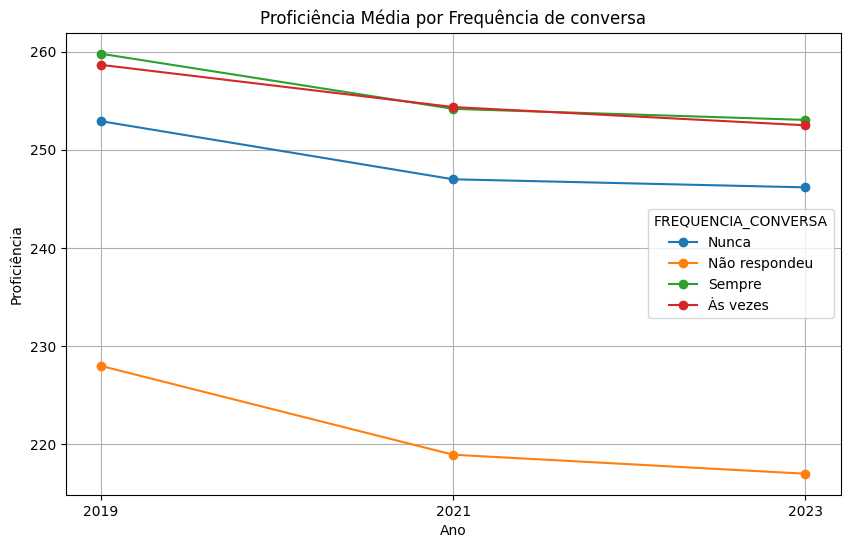

In [11]:
media_freq = (
    df_final.groupby(["ANO", "FREQUENCIA_CONVERSA"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_freq.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_freq.index)
plt.title("Proficiência Média por Frequência de conversa")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 10. Proficiência por quantidade de computador

In [58]:
tab = df_final.groupby('QTD_COMPUTADOR').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                     Média     Mediana  Desvio_Padrão  Quantidade
QTD_COMPUTADOR                                                   
0               245.464834  244.991976      47.008513     2473091
1 ou 2          262.791601  265.172124      48.378467     2550750
3 ou mais       264.347956  267.651564      52.948317      288935
Não respondeu   231.737587  230.246154      48.326604      537990


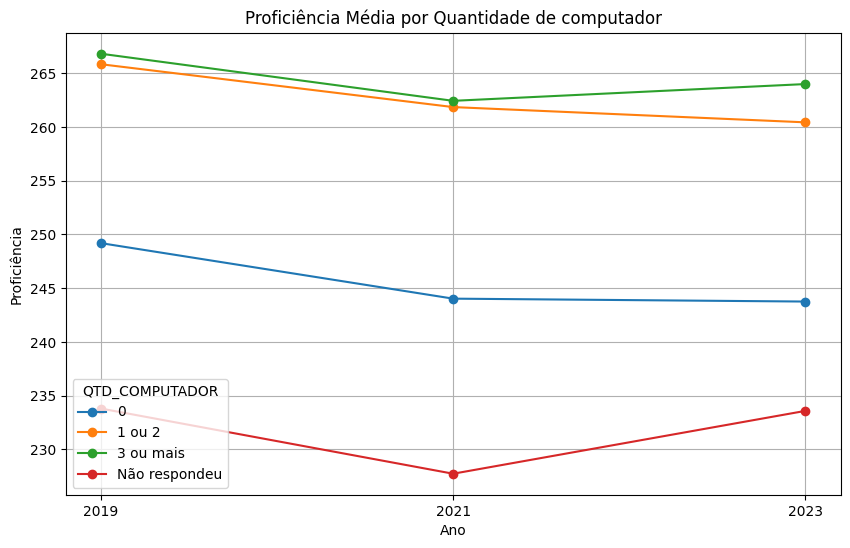

In [12]:
media_comput = (
    df_final.groupby(["ANO", "QTD_COMPUTADOR"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_comput.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_comput.index)
plt.title("Proficiência Média por Quantidade de computador")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 11. Proficiência por quantidade de carro

In [59]:
tab = df_final.groupby('QTD_CARRO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                    Média     Mediana  Desvio_Padrão  Quantidade
QTD_CARRO                                                       
0              246.397209  245.928843      47.423943     2504488
1 ou 2         261.021102  263.063922      48.678782     2829078
3 ou mais      255.840494  258.873813      50.979968      193442
Não respondeu  226.669980  223.557296      50.031443      323758


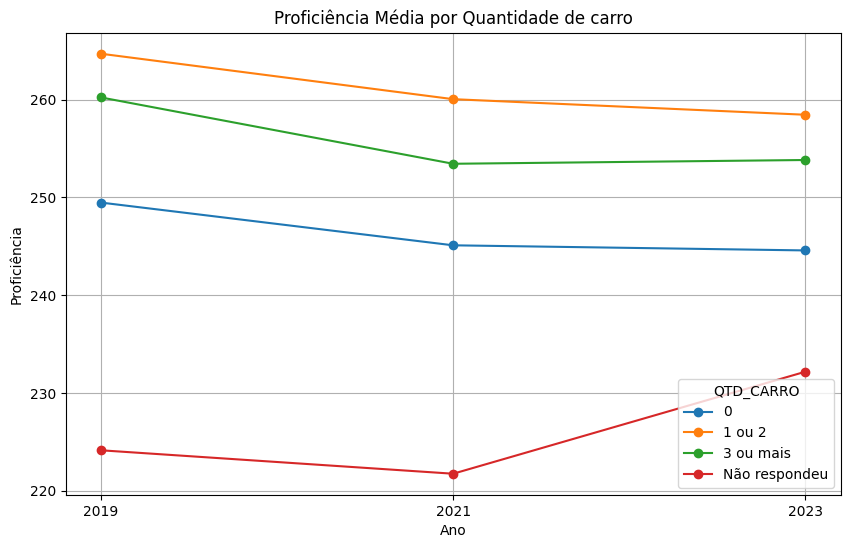

In [13]:
media_carro = (
    df_final.groupby(["ANO", "QTD_CARRO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_carro.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_carro.index)
plt.title("Proficiência Média por Quantidade de carro")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 12. Proficiência por possuimento de garagem

In [60]:
tab = df_final.groupby('GARAGEM').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                    Média     Mediana  Desvio_Padrão  Quantidade
GARAGEM                                                         
Não            246.100462  245.531393      47.798243     2246379
Não respondeu  226.647413  223.395348      50.795730      270839
Sim            259.244673  261.065380      48.714402     3333548


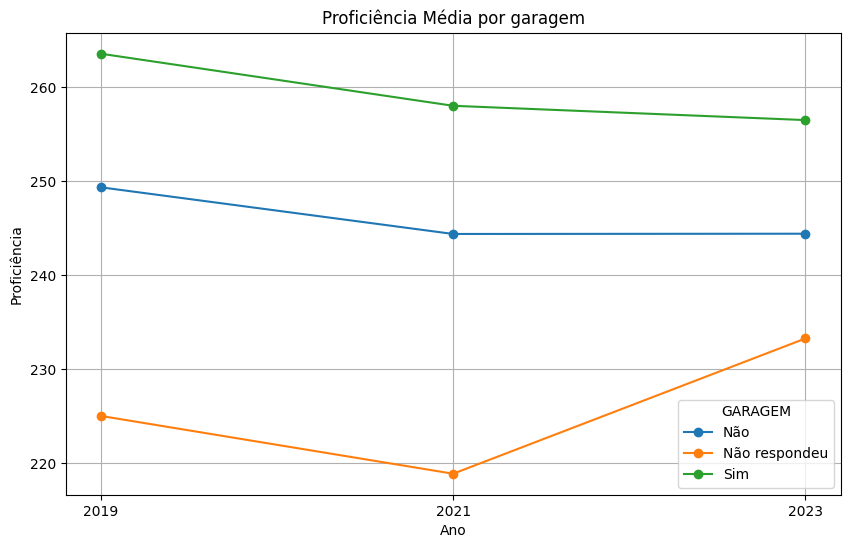

In [14]:
media_garagem = (
    df_final.groupby(["ANO", "GARAGEM"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_garagem.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_garagem.index)
plt.title("Proficiência Média por garagem")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 13. Proficiência por idade de introdução escolar

In [61]:
tab = df_final.groupby('IDADE_INTROD_ESC').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                       Média     Mediana  Desvio_Padrão  Quantidade
IDADE_INTROD_ESC                                                   
3 ou menos        253.040977  253.328400      49.890350     2117156
8 ou mais         228.915184  226.664770      47.307585      197463
Entre 4 e 7       254.824430  256.042728      48.276283     3278891
Não respondeu     240.823915  240.994641      50.261736      257256


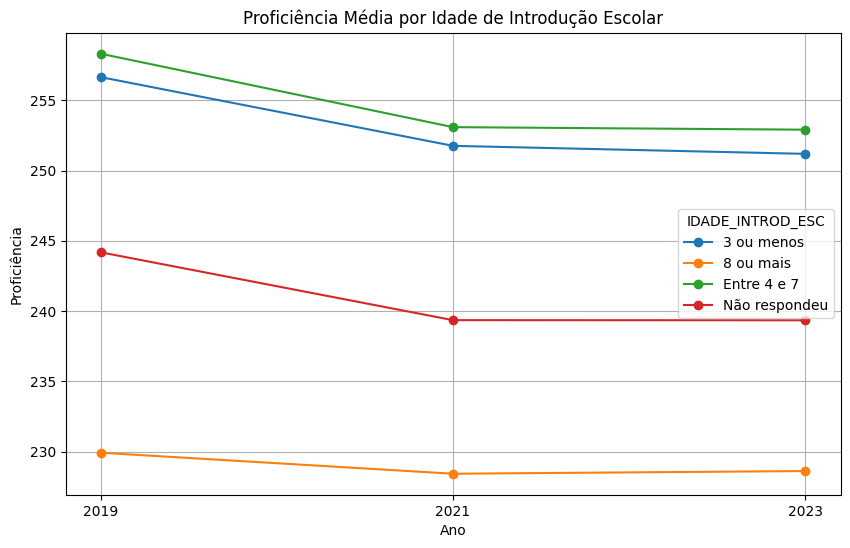

In [15]:
media_idade = (
    df_final.groupby(["ANO", "IDADE_INTROD_ESC"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_idade.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_idade.index)
plt.title("Proficiência Média por Idade de Introdução Escolar")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 14. Proficiência por reprovação

In [62]:
tab = df_final.groupby('REPROVACAO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                    Média     Mediana  Desvio_Padrão  Quantidade
REPROVACAO                                                      
Não            260.333832  261.913769      48.163096     4315245
Não respondeu  238.490258  238.294119      50.392860      235696
Sim            229.883994  228.682706      44.569953     1299825


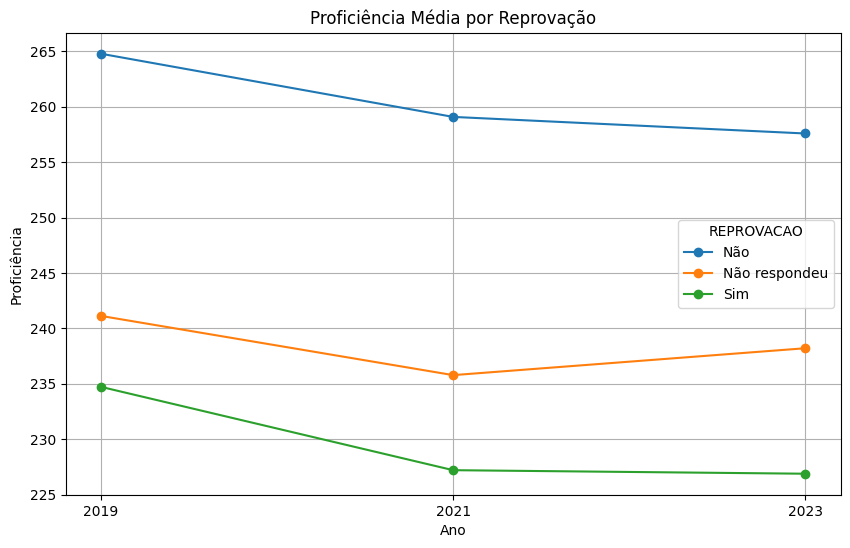

In [32]:
media_reprov = (
    df_final.groupby(["ANO", "REPROVACAO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_reprov.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_reprov.index)
plt.title("Proficiência Média por Reprovação")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 15. Proficiência por tempo gasto em trabalho doméstico

In [63]:
tab = df_final.groupby('TEMPO_TRAB_DOMES').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                                Média     Mediana  Desvio_Padrão  Quantidade
TEMPO_TRAB_DOMES                                                            
Entre 1 e 2 horas          258.967697  260.234373      47.697548     1838016
Mais de 2 horas            251.555893  251.962252      47.086477     1360842
Menos de 1 hora            255.069263  255.898469      49.614671     1749560
Não respondeu              231.021081  228.926453      50.318683      385933
Não usa o tempo para isso  241.457345  240.238892      51.189582      516415


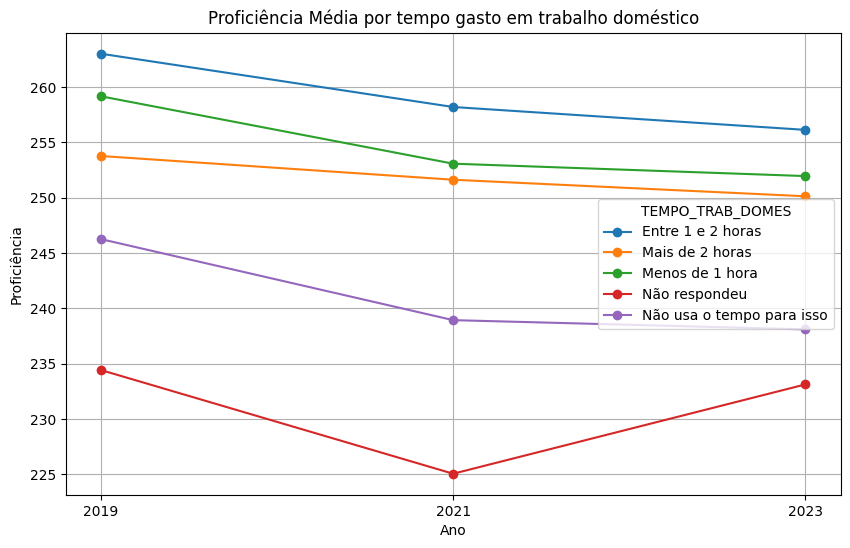

In [17]:
media_tempo_trab_dom = (
    df_final.groupby(["ANO", "TEMPO_TRAB_DOMES"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_tempo_trab_dom.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_tempo_trab_dom.index)
plt.title("Proficiência Média por tempo gasto em trabalho doméstico")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 16. Proficiência por tempo gasto em estudo

In [64]:
tab = df_final.groupby('TEMPO_ESTUDO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                                Média     Mediana  Desvio_Padrão  Quantidade
TEMPO_ESTUDO                                                                
Entre 1 e 2 horas          260.950297  262.257703      47.528289     1926840
Mais de 2 horas            251.869876  250.933722      52.352365      532965
Menos de 1 hora            252.688009  253.403687      47.691118     2428232
Não respondeu              230.764140  228.530679      50.865525      316705
Não usa o tempo para isso  239.476960  238.599794      49.980975      646024


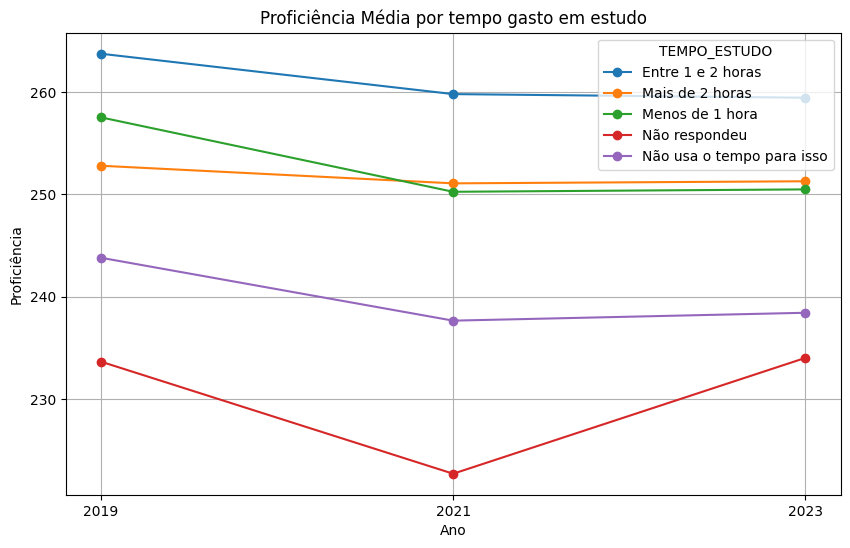

In [18]:
media_tempo_estudo = (
    df_final.groupby(["ANO", "TEMPO_ESTUDO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_tempo_estudo.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_tempo_estudo.index)
plt.title("Proficiência Média por tempo gasto em estudo")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 17. Proficiência por pretensão pós Ensino Fundamental

In [65]:
tab = df_final.groupby('POS_EF').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                          Média     Mediana  Desvio_Padrão  Quantidade
POS_EF                                                                
Estudar e trabalhar  258.079717  259.503832      47.012662     3364398
Não respondeu        238.305569  237.605106      49.508849      408578
Não sabe             242.402867  241.508822      48.435441      866398
Somente estudar      260.021704  261.357865      53.764717      804484
Somente trabalhar    229.964688  228.649255      45.529986      406908


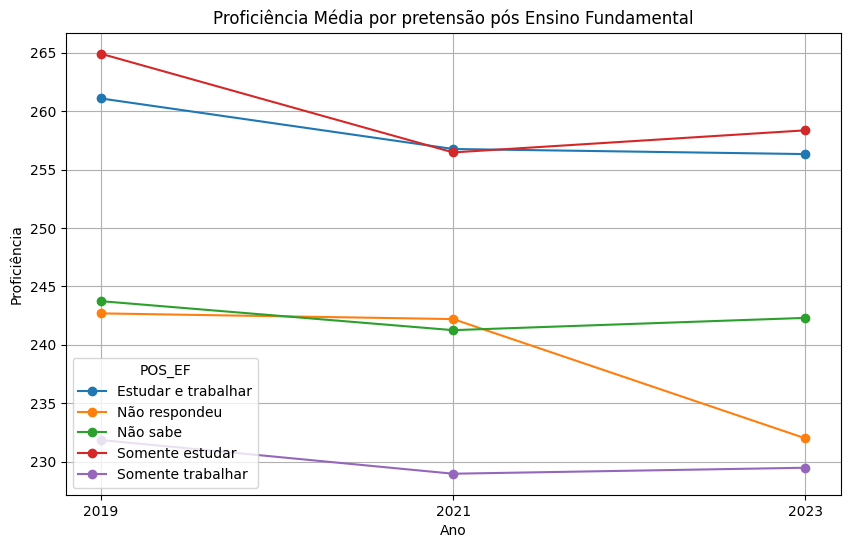

In [19]:
media_pos_ef = (
    df_final.groupby(["ANO", "POS_EF"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_pos_ef.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_pos_ef.index)
plt.title("Proficiência Média por pretensão pós Ensino Fundamental")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

Agora, serão feitas algumas análises adicionais consideradas relevantes em relação à variável 'SEXO', que só aparece nos datasets dos anos de 2021 e 2023.

In [38]:
df_final_2 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_AED.parquet", engine="pyarrow")

#### 18. Proficiência por sexo

In [66]:
tab = df_final_2.groupby('SEXO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std','count']})
tab.columns = [
    'Média',
    'Mediana',
    'Desvio_Padrão',
    'Quantidade'
]

print(tab)

                        Média     Mediana  Desvio_Padrão  Quantidade
SEXO                                                                
Feminino           248.539847  247.760323      47.020035     1897414
Masculino          254.208402  255.907412      51.070367     1907165
Não quis declarar  243.912671  243.735964      52.360502       29918
Não respondeu      235.699887  235.371341      49.460071      104338


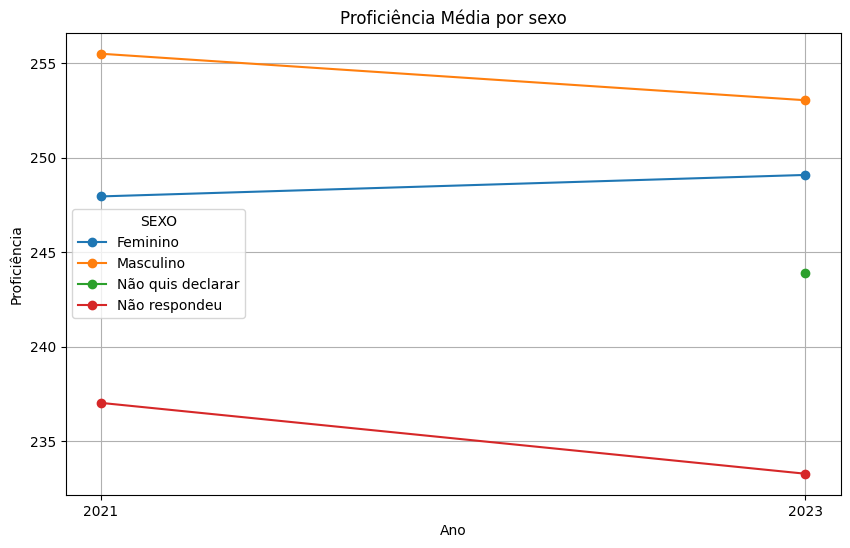

In [40]:
media_sexo = (
    df_final_2.groupby(["ANO", "SEXO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_sexo.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_sexo.index)
plt.title("Proficiência Média por sexo")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 19. Proficiência por sexo e tempo de trabaho doméstico

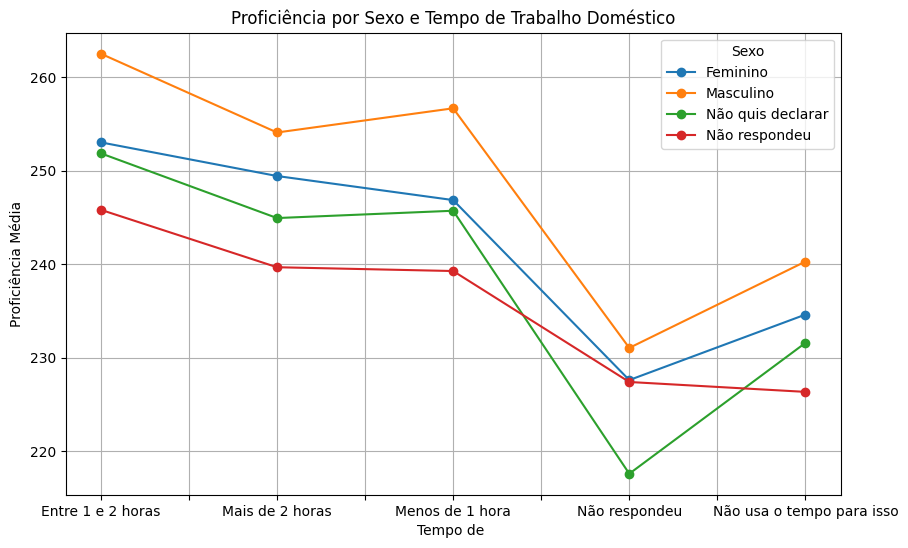

In [71]:
tab = df_final_2.groupby(
    ["TEMPO_TRAB_DOMES", "SEXO"]
)["PROFICIENCIA_SAEB"].mean().unstack()

tab.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)

plt.title("Proficiência por Sexo e Tempo de Trabalho Doméstico")
plt.xlabel("Tempo de ")
plt.ylabel("Proficiência Média")

plt.grid(True)

plt.legend(title="Sexo")

plt.show()

#### 20. Proficiência por sexo e tempo de estudo

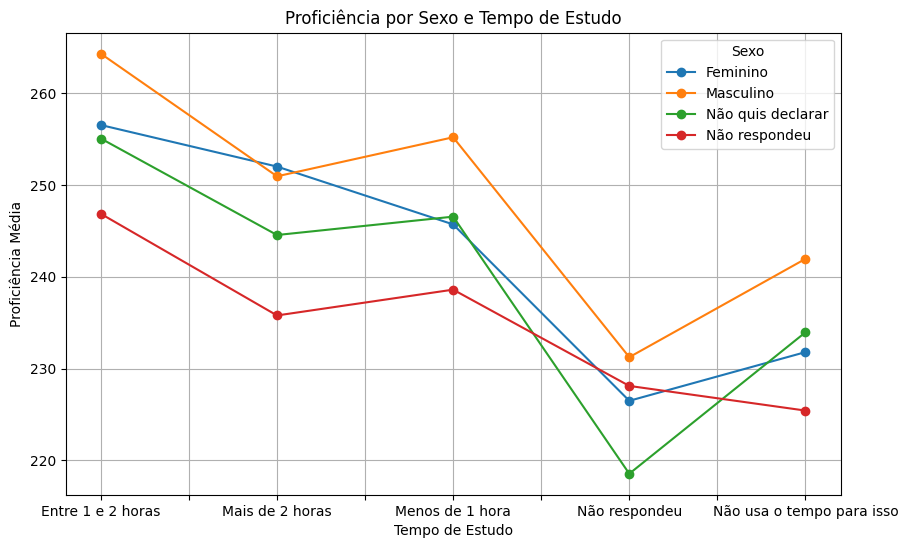

In [70]:
tab = df_final_2.groupby(
    ["TEMPO_ESTUDO", "SEXO"]
)["PROFICIENCIA_SAEB"].mean().unstack()

tab.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)

plt.title("Proficiência por Sexo e Tempo de Estudo")
plt.xlabel("Tempo de Estudo")
plt.ylabel("Proficiência Média")

plt.grid(True)

plt.legend(title="Sexo")

plt.show()